In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/Movie-Reviews-Analysis/data/IMDB Dataset.csv'
df = pd.read_csv(file_path)
df['review'] = df['review'].str.replace('<br />', ' ')
df.head(2)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming t...,positive


In [4]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [5]:
df.isnull().sum()

,0
review,0
sentiment,0


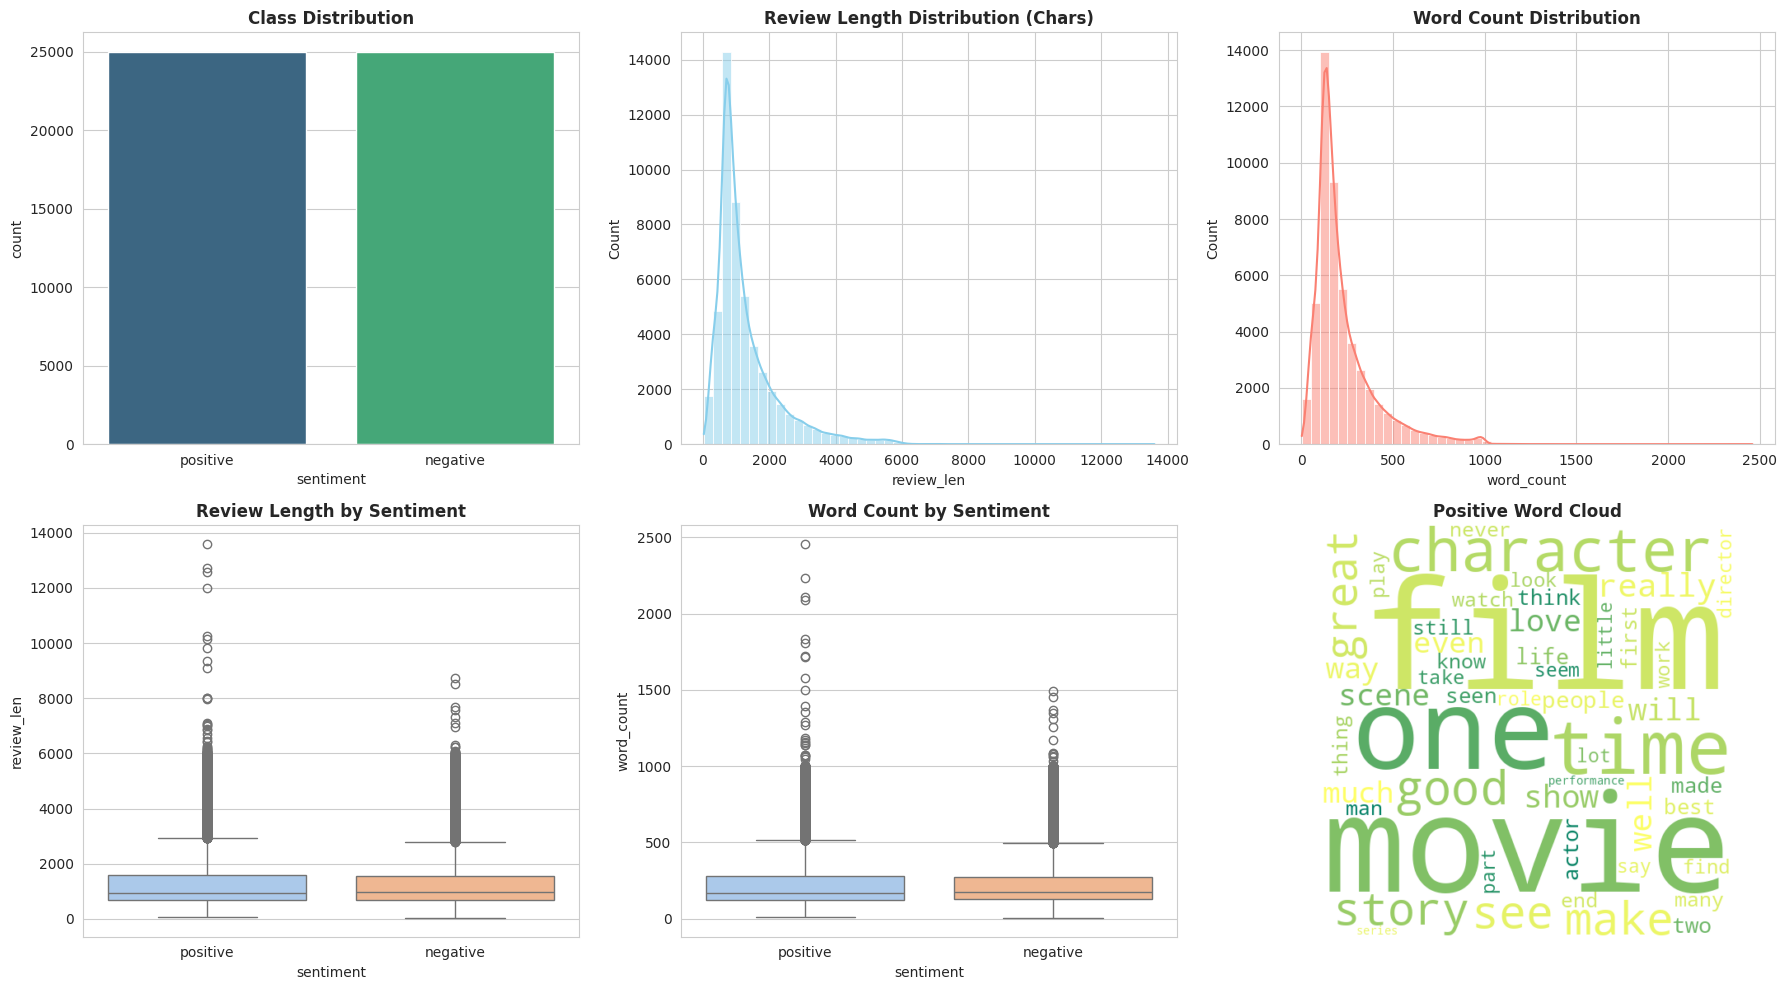

------------------------------
Dataset Summary Statistics:
       review_len  word_count
count    50000.00    50000.00
mean      1289.24      228.87
std        974.20      169.59
min         32.00        4.00
25%        691.00      125.00
50%        957.00      171.00
75%       1563.00      278.00
max      13604.00     2459.00
------------------------------


In [6]:

#  VISUAL EXPLORATORY DATA ANALYSIS


import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud


df['review_len'] = df['review'].apply(len)
df['word_count'] = df['review'].apply(lambda x: len(x.split()))


sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.3)

sns.countplot(data=df, x='sentiment', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Class Distribution', fontsize=12, fontweight='bold')

sns.histplot(df['review_len'], bins=50, ax=axes[0,1], color='skyblue', kde=True)
axes[0,1].set_title('Review Length Distribution (Chars)', fontsize=12, fontweight='bold')


sns.histplot(df['word_count'], bins=50, ax=axes[0,2], color='salmon', kde=True)
axes[0,2].set_title('Word Count Distribution', fontsize=12, fontweight='bold')

sns.boxplot(data=df, x='sentiment', y='review_len', ax=axes[1,0], palette='pastel')
axes[1,0].set_title('Review Length by Sentiment', fontsize=12, fontweight='bold')


sns.boxplot(data=df, x='sentiment', y='word_count', ax=axes[1,1], palette='pastel')
axes[1,1].set_title('Word Count by Sentiment', fontsize=12, fontweight='bold')

pos_data = ' '.join(df[df['sentiment']=='positive']['review'].sample(1000))
wc = WordCloud(width=500, height=500, background_color='white',
               colormap='summer', max_words=50).generate(pos_data)

axes[1,2].imshow(wc, interpolation='bilinear')
axes[1,2].set_title('Positive Word Cloud', fontsize=12, fontweight='bold')
axes[1,2].axis('off')

plt.tight_layout()
plt.savefig('eda_report.png', dpi=200)
plt.show()

print("-" * 30)
print("Dataset Summary Statistics:")
print(df[['review_len', 'word_count']].describe().round(2))
print("-" * 30)

In [7]:
#   TRAIN-TEST SPLIT


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df['review']
y = df['sentiment']


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"label mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size:  {X_test.shape[0]}")

# Verification of class balance across splits
def get_dist(y):
    return pd.Series(y).value_counts(normalize=True).to_dict()

train_dist = get_dist(y_train)
test_dist  = get_dist(y_test)

print("\nClass Distribution Check (Proportions):")
print(f"Training -> Negative: {train_dist[0]:.4f}, Positive: {train_dist[1]:.4f}")
print(f"Testing  -> Negative: {test_dist[0]:.4f}, Positive: {test_dist[1]:.4f}")

# Sanity check for stratification
diff = abs(train_dist[1] - test_dist[1])
print(f"\nStratification Delta: {diff:.6f}")
if diff < 0.01:
    print("Status: Stratification successful.")

label mapping: {'negative': np.int64(0), 'positive': np.int64(1)}
Train set size: 40000
Test set size:  10000

Class Distribution Check (Proportions):
Training -> Negative: 0.5000, Positive: 0.5000
Testing  -> Negative: 0.5000, Positive: 0.5000

Stratification Delta: 0.000000
Status: Stratification successful.


In [8]:
# TEXT VECTORIZATION

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# CountVectorizer
count_vec = CountVectorizer(max_features=10000, ngram_range=(1, 3),
                            min_df=5, max_df=0.7, stop_words='english')
X_train_count = count_vec.fit_transform(X_train)
X_test_count = count_vec.transform(X_test)

print(f"CountVectorizer: {X_train_count.shape[1]:,} features")

# TF-IDF Vectorizer
tfidf_vec = TfidfVectorizer(max_features=10000, ngram_range=(1, 3),
                            min_df=5, max_df=0.7, stop_words='english',
                            sublinear_tf=True)
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

print(f"TF-IDF: {X_train_tfidf.shape[1]:,} features")

# Quick peek at top features
feature_names = count_vec.get_feature_names_out()
word_freq = X_train_count.sum(axis=0).A1
top_idx = word_freq.argsort()[-20:][::-1]
print("\nTop 10 features:", [feature_names[i] for i in top_idx[:10]])

CountVectorizer: 10,000 features
TF-IDF: 10,000 features

Top 10 features: ['movie', 'film', 'like', 'just', 'good', 'time', 'really', 'story', 'bad', 'people']


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Linear SVM': LinearSVC(max_iter=2000, C=1.0, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
}

print(f"Models: {list(models.keys())}")

Models: ['Logistic Regression', 'Naive Bayes', 'Linear SVM', 'Random Forest']


In [10]:
# Train with CountVectorizer

results_count = {}

for name, model in models.items():
    print(f"\n{name}...")
    start = time.time()

    model.fit(X_train_count, y_train)
    y_pred = model.predict(X_test_count)
    acc = (y_pred == y_test).mean()

    results_count[name] = {'acc': acc, 'time': time.time() - start}
    print(f"  acc: {acc:.4f} ({results_count[name]['time']:.2f}s)")

print("\nCountVectorizer Results:")
print(pd.DataFrame(results_count).T.round(4))


Logistic Regression...
  acc: 0.8760 (2.91s)

Naive Bayes...
  acc: 0.8579 (0.03s)

Linear SVM...
  acc: 0.8510 (45.62s)

Random Forest...
  acc: 0.8348 (9.88s)

CountVectorizer Results:
                        acc     time
Logistic Regression  0.8760   2.9133
Naive Bayes          0.8579   0.0327
Linear SVM           0.8510  45.6233
Random Forest        0.8348   9.8757


In [11]:
# Train with TF-IDF
results_tfidf = {}

for name, model in models.items():
    print(f"\n{name}...")
    start = time.time()


    if name == 'Naive Bayes':
        model = MultinomialNB(alpha=0.1)
    elif name == 'Linear SVM':
        model = LinearSVC(max_iter=2000, C=1.0, random_state=42)
    elif name == 'Logistic Regression':
        model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    else:
        model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)

    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = (y_pred == y_test).mean()

    results_tfidf[name] = {'acc': acc, 'time': time.time() - start}
    print(f"  acc: {acc:.4f} ({results_tfidf[name]['time']:.2f}s)")

print("\nTF-IDF Results:")
print(pd.DataFrame(results_tfidf).T.round(4))


Logistic Regression...
  acc: 0.9008 (0.30s)

Naive Bayes...
  acc: 0.8640 (0.04s)

Linear SVM...
  acc: 0.8910 (0.89s)

Random Forest...
  acc: 0.8340 (13.21s)

TF-IDF Results:
                        acc     time
Logistic Regression  0.9008   0.2985
Naive Bayes          0.8640   0.0398
Linear SVM           0.8910   0.8948
Random Forest        0.8340  13.2102


In [12]:
# Compare Vectorizers

comparison = pd.DataFrame({
    'Model': list(results_count.keys()),
    'Count': [results_count[m]['acc'] for m in results_count],
    'TF-IDF': [results_tfidf[m]['acc'] for m in results_tfidf]
})
comparison['Diff'] = comparison['TF-IDF'] - comparison['Count']

print(comparison.round(4))

best_model = comparison.loc[comparison['TF-IDF'].idxmax(), 'Model']
best_acc = comparison['TF-IDF'].max()
best_vec = 'TF-IDF' if comparison.loc[comparison['Model']==best_model, 'TF-IDF'].values[0] > \
                        comparison.loc[comparison['Model']==best_model, 'Count'].values[0] else 'Count'

print(f"\nBest: {best_model} ({best_vec}) with {best_acc:.4f}")

                 Model   Count  TF-IDF    Diff
0  Logistic Regression  0.8760  0.9008  0.0248
1          Naive Bayes  0.8579  0.8640  0.0061
2           Linear SVM  0.8510  0.8910  0.0400
3        Random Forest  0.8348  0.8340 -0.0008

Best: Logistic Regression (TF-IDF) with 0.9008



Logistic Regression Performance:
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



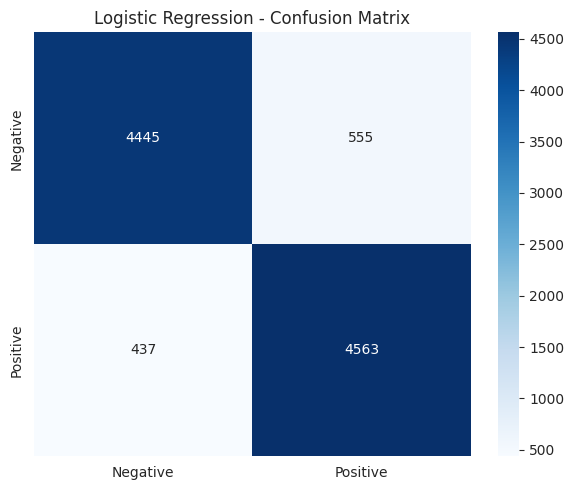

In [13]:
# Detailed Report

from sklearn.metrics import classification_report, confusion_matrix

# Get best model predictions
if best_vec == 'TF-IDF':
    model = LogisticRegression(max_iter=1000, C=1.0, random_state=42) if best_model == 'Logistic Regression' else \
            MultinomialNB(alpha=0.1) if best_model == 'Naive Bayes' else \
            LinearSVC(max_iter=2000, C=1.0, random_state=42) if best_model == 'Linear SVM' else \
            RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
else:
    model = LogisticRegression(max_iter=1000, C=1.0, random_state=42) if best_model == 'Logistic Regression' else \
            MultinomialNB(alpha=0.1) if best_model == 'Naive Bayes' else \
            LinearSVC(max_iter=2000, C=1.0, random_state=42) if best_model == 'Linear SVM' else \
            RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
    model.fit(X_train_count, y_train)
    y_pred = model.predict(X_test_count)

print(f"\n{best_model} Performance:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], cmap='Blues')
plt.title(f'{best_model} - Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Movie-Reviews-Analysis/images/confusion_matrix.png', dpi=150)
plt.show()

In [14]:
# Sample Predictions

# Get random test samples
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), 10, replace=False)
samples = X_test.iloc[sample_idx]
true_labels = y_test[sample_idx]

if best_vec == 'TF-IDF':
    sample_vec = tfidf_vec.transform(samples)
else:
    sample_vec = count_vec.transform(samples)

preds = model.predict(sample_vec)

print("\nSample Predictions:")
print("-" * 80)
for i, (text, true, pred) in enumerate(zip(samples, true_labels, preds)):
    print(f"\n{i+1}. {text[:150]}...")
    print(f"   True: {'Positive' if true==1 else 'Negative'}")
    print(f"   Pred: {'Positive' if pred==1 else 'Negative'} {'✓' if true==pred else '✗'}")


Sample Predictions:
--------------------------------------------------------------------------------

1. This is loosely based on the ideas of the original 80's hit . It's set in the modern day as we see a base in Afghanistan get destroyed by a UAV right ...
   True: Negative
   Pred: Negative ✓

2. This movie was on British TV last night, and is wonderful! Strong women, great music (most of the time) and just makes you think. We do have stereotyp...
   True: Positive
   Pred: Positive ✓

3. What a dreadful movie. The effects were poor, especially by todays standards, but that was forgivable. What was unforgivable was the terrible rehashin...
   True: Negative
   Pred: Negative ✓

4. I'll keep this short, as I know I don't need to say much.  "Alive" is a strange little film that obviously appeals to some, but I found it to be shock...
   True: Negative
   Pred: Negative ✓

5. I don't know what the rest of you guys watch Steven Seagal movies for, but I watch them because, as silly as t

In [15]:
import pickle

# Save for zero-shot notebook
test_data = {
    'X_test': X_test,
    'y_test': y_test,
    'best_model': best_model,
    'best_acc': best_acc,
    'best_vec': best_vec,
    'y_pred': y_pred
}

with open('/content/drive/MyDrive/Movie-Reviews-Analysis/data/test_data.pkl', 'wb') as f:
    pickle.dump(test_data, f)

# Save comparison results
comparison.to_csv('/content/drive/MyDrive/Movie-Reviews-Analysis/data/model_comparison.csv', index=False)


print("SUMMARY")
print(f"Dataset: {len(df):,} reviews")
print(f"Best model: {best_model}")
print(f"Best vectorizer: {best_vec}")
print(f"Best accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print("="*60)


SUMMARY
Dataset: 50,000 reviews
Best model: Logistic Regression
Best vectorizer: TF-IDF
Best accuracy: 0.9008 (90.08%)
